In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
from imblearn.over_sampling import SMOTE
import joblib
import warnings
warnings.filterwarnings('ignore')

print("All libraries imported successfully!")

All libraries imported successfully!


In [2]:
df = pd.read_csv('../data/creditcard.csv')
print("Shape:", df.shape)
df.head()

Shape: (284807, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [3]:
# Scale Amount and Time columns
scaler = StandardScaler()
df['scaled_amount'] = scaler.fit_transform(df[['Amount']])
df['scaled_time'] = scaler.fit_transform(df[['Time']])

# Drop original Amount and Time
df.drop(['Amount', 'Time'], axis=1, inplace=True)

print("Scaling done!")
print(df.shape)

Scaling done!
(284807, 31)


In [4]:
X = df.drop('Class', axis=1)
y = df['Class']

print("Features shape:", X.shape)
print("Target shape:", y.shape)
print("\nClass distribution:")
print(y.value_counts())

Features shape: (284807, 30)
Target shape: (284807,)

Class distribution:
Class
0    284315
1       492
Name: count, dtype: int64


In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Training set size:", X_train.shape)
print("Test set size:", X_test.shape)

Training set size: (227845, 30)
Test set size: (56962, 30)


In [6]:
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("Before SMOTE:", y_train.value_counts().to_dict())
print("After SMOTE:", pd.Series(y_train_smote).value_counts().to_dict())

Before SMOTE: {0: 227451, 1: 394}
After SMOTE: {0: 227451, 1: 227451}


In [7]:
models = {
    'Logistic Regression': LogisticRegression(random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'XGBoost': XGBClassifier(random_state=42, eval_metric='logloss'),
    'LightGBM': LGBMClassifier(random_state=42, verbose=-1)
}

results = {}

for name, model in models.items():
    print(f"Training {name}...")
    model.fit(X_train_smote, y_train_smote)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    roc_auc = roc_auc_score(y_test, y_prob)
    results[name] = {
        'model': model,
        'y_pred': y_pred,
        'y_prob': y_prob,
        'roc_auc': roc_auc
    }
    print(f"✅ {name} — ROC AUC: {roc_auc:.4f}\n")

Training Logistic Regression...
✅ Logistic Regression — ROC AUC: 0.9698

Training Random Forest...
✅ Random Forest — ROC AUC: 0.9688

Training XGBoost...
✅ XGBoost — ROC AUC: 0.9792

Training LightGBM...
✅ LightGBM — ROC AUC: 0.9694



In [9]:
print("=" * 50)
print("MODEL COMPARISON")
print("=" * 50)

for name, result in results.items():
    print(f"\n{name}")
    print(f"ROC AUC: {result['roc_auc']:.4f}")
    print(classification_report(y_test, result['y_pred'], 
          target_names=['Legitimate', 'Fraud']))

MODEL COMPARISON

Logistic Regression
ROC AUC: 0.9698
              precision    recall  f1-score   support

  Legitimate       1.00      0.97      0.99     56864
       Fraud       0.06      0.92      0.11        98

    accuracy                           0.97     56962
   macro avg       0.53      0.95      0.55     56962
weighted avg       1.00      0.97      0.99     56962


Random Forest
ROC AUC: 0.9688
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00     56864
       Fraud       0.81      0.81      0.81        98

    accuracy                           1.00     56962
   macro avg       0.91      0.90      0.90     56962
weighted avg       1.00      1.00      1.00     56962


XGBoost
ROC AUC: 0.9792
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00     56864
       Fraud       0.73      0.89      0.80        98

    accuracy                           1.00     56962
   macro avg      

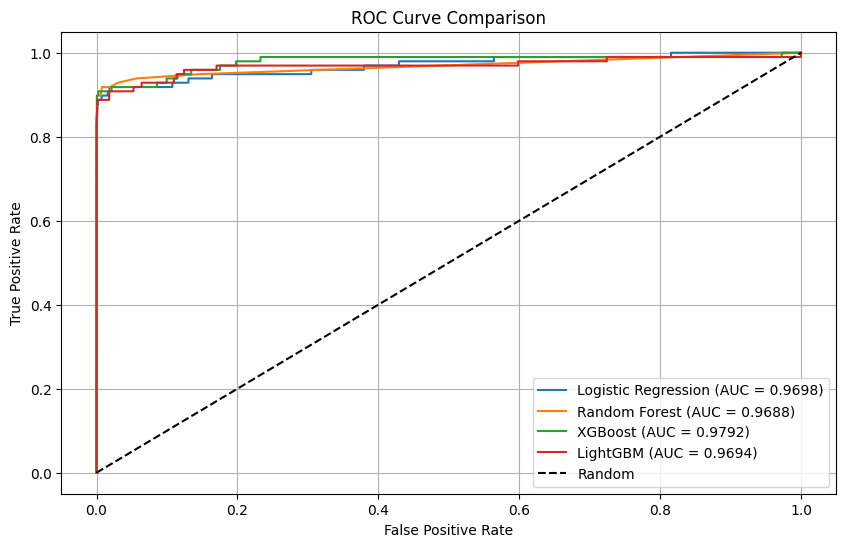

In [10]:
plt.figure(figsize=(10, 6))

for name, result in results.items():
    fpr, tpr, _ = roc_curve(y_test, result['y_prob'])
    plt.plot(fpr, tpr, label=f"{name} (AUC = {result['roc_auc']:.4f})")

plt.plot([0, 1], [0, 1], 'k--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend()
plt.grid(True)
plt.show()

In [11]:
# Find best model by ROC AUC
best_name = max(results, key=lambda x: results[x]['roc_auc'])
best_model = results[best_name]['model']

print(f"Best Model: {best_name}")
print(f"Best ROC AUC: {results[best_name]['roc_auc']:.4f}")

# Save model
joblib.dump(best_model, '../models/best_model.pkl')
joblib.dump(scaler, '../models/scaler.pkl')

print("\n✅ Model saved to models/best_model.pkl")

Best Model: XGBoost
Best ROC AUC: 0.9792

✅ Model saved to models/best_model.pkl
